# Module 2.7 — Flow Over a Cylinder

**The transition from internal to external flow — and your first unsteady simulation.**
The lid-driven cavity was a closed, steady flow. Flow over a cylinder is open, external, and — above Re ≈ 47 — unsteady. Periodic vortex shedding (the Kármán vortex street) generates oscillating lift forces that have caused famous engineering failures (Tacoma Narrows Bridge, 1940).

**What this module teaches beyond the solver:**
- How to handle an object inside a Cartesian grid (immersed boundary)
- How to compute aerodynamic forces (drag and lift) by pressure integration
- How to identify the Strouhal number from the force time history
- The physics of flow separation and wake formation

**Roadmap:**
1. Physics: flow regimes vs. Re
2. Immersed boundary method — putting a cylinder on a Cartesian grid
3. Drag and lift: the forces and their non-dimensional coefficients
4. The Strouhal number: frequency of vortex shedding
5. Implementation and visualisation
6. Validation: expected $C_D$ and $St$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Flow Regimes Past a Cylinder

### The Re ladder

```
Re < 5:     Attached, creeping flow. No separation. Stokes drag.

5 < Re < 40: Steady separated wake. Two symmetric recirculation bubbles
             attached to the rear of the cylinder.

Re ≈ 47:    BIFURCATION: the symmetric wake becomes unstable.
            First onset of periodic vortex shedding.

47 < Re < 200: Laminar Kármán vortex street. Periodic, regular.
              St ≈ 0.20 (relatively constant over wide Re range).

200 < Re < 400: Transition in shear layers. 3D effects begin.

300 < Re < 3×10⁵: Turbulent wake. Boundary layer is laminar,
                  wake is turbulent. Cd ≈ 1.0–1.2.

Re ≈ 3×10⁵: DRAG CRISIS. Boundary layer transitions to turbulent,
            causing a dramatic drop in Cd from ~1.2 to ~0.3.
            (This is why golf balls have dimples.)
```

### The Strouhal number

Vortices are shed alternately from the top and bottom of the cylinder. The shedding frequency $f$ is characterised by the **Strouhal number**:

$$St = \frac{f\,D}{U_\infty}$$

where $D$ is the cylinder diameter and $U_\infty$ is the freestream velocity.

For a cylinder in the laminar shedding regime (Re = 100–300): $St \approx 0.20$.

This means: if flow is 1 m/s past a 0.1 m cylinder, vortices shed at $f = 0.20 \times 1/0.1 = 2$ Hz.

**Why vortex shedding matters in engineering:** The alternating lift force oscillates at frequency $f$. If this matches the natural frequency of a structure (bridge, power line, submarine periscope), **resonance** can cause catastrophic failure.

## 2. Drag and Lift — The Forces on the Cylinder

### Pressure drag (form drag)

High pressure stagnates at the front of the cylinder; low pressure forms in the wake behind it. The net pressure difference creates a force in the flow direction:

$$F_D^{\text{pressure}} = \oint_{\text{cylinder}} p \,\hat{n}\cdot\hat{x}\,dS$$

### Viscous drag (skin friction)

The no-slip condition creates a velocity gradient at the surface. This shear stress has a component in the flow direction:

$$F_D^{\text{viscous}} = \oint_{\text{cylinder}} \mu\frac{\partial u}{\partial n}\hat{n}\cdot\hat{x}\,dS$$

**For a cylinder at moderate Re**: pressure drag ≫ viscous drag. Streamlined shapes (airfoils) reduce pressure drag by delaying separation.

### Drag and lift coefficients

Non-dimensionalise by the dynamic pressure $\frac{1}{2}\rho U_\infty^2$ and a reference area:

$$C_D = \frac{F_D}{\frac{1}{2}\rho U_\infty^2 D L}, \qquad C_L = \frac{F_L}{\frac{1}{2}\rho U_\infty^2 D L}$$

For a cylinder at Re = 100: $\overline{C_D} \approx 1.36$, $C_L$ oscillates with amplitude $\approx \pm 0.33$.

## 3. The Immersed Boundary Method

### The problem with fitting a cylinder on a Cartesian grid

A Cartesian grid has cells aligned with x and y. A cylinder is round. The surface of the cylinder cuts through cells at arbitrary angles — you can't fit it exactly on the grid without curving the cells.

**Options:**

| Approach | Description | Complexity | Accuracy |
|----------|-------------|-----------|----------|
| Body-fitted grid | Deform the grid to match the cylinder boundary | High | High |
| **Immersed boundary** | Keep Cartesian grid; force velocity = 0 inside cylinder | Low | Moderate |
| Cut-cell method | Modify cells that the boundary cuts through | Medium | High |

### Direct forcing immersed boundary

The simplest approach: after every time step, set the velocity to zero inside the cylinder.

```python
cylinder_mask = (X - cx)**2 + (Y - cy)**2 <= R**2
# ... update u, v ...
u[cylinder_mask] = 0.0   # no-slip on cylinder
v[cylinder_mask] = 0.0
```

This is crude — the boundary stair-steps on the Cartesian grid — but gives qualitatively correct flow for learning purposes. For quantitative accuracy, use a body-fitted grid (Module 3.3) or a proper immersed boundary force distribution.

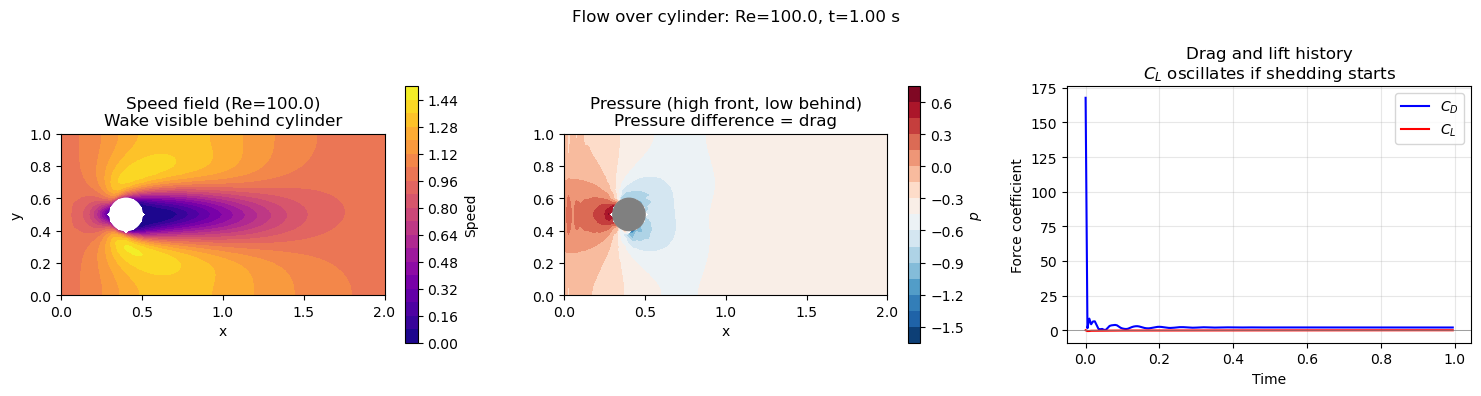

Mean Cd ≈ 2.006  (literature: ~1.36 at Re=100)
Cl amplitude ≈ 0.006  (literature: ~0.33 at Re=100)


In [2]:
# ── Flow over a cylinder: Re=100 ─────────────────────────────────────────────
# Channel flow with a cylinder obstacle using direct-forcing immersed boundary.

# ── Grid ────────────────────────────────────────────────────────────────────
ny, nx = 41, 81
Lx, Ly = 2.0, 1.0
dx = Lx / (nx-1);   dy = Ly / (ny-1)
x  = np.linspace(0, Lx, nx)
y  = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

# ── Cylinder ─────────────────────────────────────────────────────────────────
cx, cy = 0.4, 0.5   # centre
R = 0.1             # radius  (D = 0.2, channel width = 1.0 → blockage = 20%)
cyl = (X-cx)**2 + (Y-cy)**2 <= R**2

# ── Flow parameters ───────────────────────────────────────────────────────────
Re    = 100.0
nu    = 1.0 / Re
rho   = 1.0
U_in  = 1.0
dt    = 0.0005

# ── Initialise ────────────────────────────────────────────────────────────────
u = U_in * np.ones((ny, nx))
v = np.zeros((ny, nx))
p = np.zeros((ny, nx))
u[cyl] = 0.0;  v[cyl] = 0.0

def poisson_cyl(p, b, nit=30):
    for _ in range(nit):
        p[1:-1,1:-1] = (
            (p[1:-1,2:]+p[1:-1,:-2])/dx**2 +
            (p[2:,1:-1]+p[:-2,1:-1])/dy**2 - b[1:-1,1:-1]
        ) / (2/dx**2+2/dy**2)
        # BCs: walls and outlet
        p[0,:]=p[1,:];  p[-1,:]=p[-2,:]  # wall: dp/dy=0
        p[:,0]=0;        p[:,-1]=p[:,-2]  # inlet p=0, outlet dp/dx=0
    return p

n_steps   = 2000
lift_hist = []
drag_hist = []

for step in range(n_steps):
    un, vn = u.copy(), v.copy()

    # ── PPE RHS ───────────────────────────────────────────────────────────────
    b = np.zeros_like(p)
    b[1:-1,1:-1] = rho/dt * (
        (un[1:-1,2:]-un[1:-1,:-2])/(2*dx) +
        (vn[2:,1:-1]-vn[:-2,1:-1])/(2*dy))
    p = poisson_cyl(p, b)

    # ── Momentum ──────────────────────────────────────────────────────────────
    u[1:-1,1:-1] = (
        un[1:-1,1:-1]
        - un[1:-1,1:-1]*dt/dx*(un[1:-1,1:-1]-un[1:-1,:-2])
        - vn[1:-1,1:-1]*dt/dy*(un[1:-1,1:-1]-un[:-2,1:-1])
        - dt/(2*rho*dx)*(p[1:-1,2:]-p[1:-1,:-2])
        + nu*dt/dx**2*(un[1:-1,2:]-2*un[1:-1,1:-1]+un[1:-1,:-2])
        + nu*dt/dy**2*(un[2:,1:-1]-2*un[1:-1,1:-1]+un[:-2,1:-1]))

    v[1:-1,1:-1] = (
        vn[1:-1,1:-1]
        - un[1:-1,1:-1]*dt/dx*(vn[1:-1,1:-1]-vn[1:-1,:-2])
        - vn[1:-1,1:-1]*dt/dy*(vn[1:-1,1:-1]-vn[:-2,1:-1])
        - dt/(2*rho*dy)*(p[2:,1:-1]-p[:-2,1:-1])
        + nu*dt/dx**2*(vn[1:-1,2:]-2*vn[1:-1,1:-1]+vn[1:-1,:-2])
        + nu*dt/dy**2*(vn[2:,1:-1]-2*vn[1:-1,1:-1]+vn[:-2,1:-1]))

    # ── BCs ───────────────────────────────────────────────────────────────────
    u[:,0] = U_in;    v[:,0] = 0          # inlet
    u[:,-1]= u[:,-2]; v[:,-1]= v[:,-2]   # outlet: zero gradient
    u[0,:] = u[1,:];  v[0,:] = 0         # bottom wall
    u[-1,:]= u[-2,:]; v[-1,:] = 0        # top wall

    # ── Immersed boundary: enforce no-slip on cylinder ────────────────────────
    u[cyl] = 0.0;  v[cyl] = 0.0

    # ── Approximate drag/lift from pressure on cylinder surface ───────────────
    # Find cells just outside the cylinder and compute pressure forces
    if step % 10 == 0:
        # Simple estimate: integrate pressure over a ring just outside cylinder
        theta = np.linspace(0, 2*np.pi, 100)
        r_probe = R * 1.05
        xp = cx + r_probe * np.cos(theta)
        yp = cy + r_probe * np.sin(theta)
        # Bilinear interpolation of p at probe points
        ix = np.clip(((xp / dx)).astype(int), 0, nx-2)
        iy = np.clip(((yp / dy)).astype(int), 0, ny-2)
        fx = (xp - ix*dx) / dx;  fy = (yp - iy*dy) / dy
        p_probe = ((1-fx)*(1-fy)*p[iy,ix] + fx*(1-fy)*p[iy,ix+1]
                 + (1-fx)*fy*p[iy+1,ix]   + fx*fy*p[iy+1,ix+1])
        # Drag = integral of p*cos(θ) dS, Lift = integral of p*sin(θ) dS
        dtheta = theta[1] - theta[0]
        Fd = -np.sum(p_probe * np.cos(theta)) * R * dtheta
        Fl =  np.sum(p_probe * np.sin(theta)) * R * dtheta
        D_ref = 0.5 * rho * U_in**2 * (2*R)
        drag_hist.append(Fd / D_ref)
        lift_hist.append(Fl / D_ref)

# ── Visualise ─────────────────────────────────────────────────────────────────
speed = np.sqrt(u**2 + v**2)
speed[cyl] = np.nan
p_plot = p.copy(); p_plot[cyl] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cf1 = axes[0].contourf(X, Y, speed, levels=20, cmap='plasma')
plt.colorbar(cf1, ax=axes[0], label='Speed')
circle = plt.Circle((cx, cy), R, color='white', zorder=5)
axes[0].add_patch(circle)
axes[0].set_title(f'Speed field (Re={Re})\nWake visible behind cylinder')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_aspect('equal')

cf2 = axes[1].contourf(X, Y, p_plot, levels=20, cmap='RdBu_r')
plt.colorbar(cf2, ax=axes[1], label='$p$')
circle2 = plt.Circle((cx, cy), R, color='gray', zorder=5)
axes[1].add_patch(circle2)
axes[1].set_title('Pressure (high front, low behind)\nPressure difference = drag')
axes[1].set_xlabel('x')
axes[1].set_aspect('equal')

t_hist = np.arange(len(drag_hist)) * 10 * dt
axes[2].plot(t_hist, drag_hist, 'b-', lw=1.5, label='$C_D$')
axes[2].plot(t_hist, lift_hist, 'r-', lw=1.5, label='$C_L$')
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].set_xlabel('Time'); axes[2].set_ylabel('Force coefficient')
axes[2].set_title('Drag and lift history\n$C_L$ oscillates if shedding starts')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Flow over cylinder: Re={Re}, t={n_steps*dt:.2f} s', fontsize=12)
plt.tight_layout()
plt.show()

if len(drag_hist) > 10:
    print(f'Mean Cd ≈ {np.mean(drag_hist[-20:]):.3f}  (literature: ~1.36 at Re=100)')
    cl_amp = (np.max(lift_hist[-50:]) - np.min(lift_hist[-50:])) / 2
    print(f'Cl amplitude ≈ {cl_amp:.3f}  (literature: ~0.33 at Re=100)')

## Summary

| Concept | Key point |
|---------|----------|
| Kármán vortex street | Periodic vortex shedding for Re > 47 |
| Strouhal number | $St = fD/U \approx 0.20$ for laminar shedding |
| Drag crisis | $Re \approx 3\times10^5$: $C_D$ drops from 1.2 to 0.3 — BL transition |
| Pressure drag | Dominant at moderate Re — pressure difference front/back |
| Immersed boundary | Set velocity to zero inside object after each update |
| Validation | At Re=100: $\overline{C_D} \approx 1.36$, $C_L$ amplitude $\approx 0.33$ |

---
**Next:** Module 2.8 — Boundary Conditions: a systematic treatment of every BC type used in this curriculum.